In [1]:
# %% [markdown]
# # cGAN 反事實生成模型訓練
# 
# 本 Notebook 用於訓練條件生成對抗網路（cGAN），生成反事實影像。
# 
# ## 訓練目標
# 1. 生成與原圖相似但分類結果相反的影像
# 2. 確保生成影像的真實性
# 3. 最小化影像變化量
# 
# ## 損失函數
# - 對抗損失：確保生成影像真實
# - 分類損失：確保分類結果反轉
# - L1 損失：保持與原圖相似
# - 感知損失：保持高層特徵相似

# %%
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 加入專案路徑
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from data.dataset import CXRDataset
from data.preprocessing import ImagePreprocessor, DataAugmentor
from models.classifier import CXRClassifier, load_checkpoint
from models.generator import UNetGenerator, ResidualGenerator
from models.discriminator import PatchGANDiscriminator, SpectralNormDiscriminator, initialize_weights
from models.losses import GANLoss, PerceptualLoss, ClassificationLoss, CounterfactualLoss
from utils.metrics import CounterfactualMetrics

print("✅ 套件載入完成")

# %% [markdown]
# ## 1. 設定與路徑

# %%
# 裝置設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

# 路徑設定
DATA_ROOT = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_ROOT / "raw" / "images"
CLASSIFIER_PATH = PROJECT_ROOT / "models" / "classifier" / "best_model.pth"
MODELS_DIR = PROJECT_ROOT / "models" / "generator"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n路徑設定:")
print(f"  分類器: {CLASSIFIER_PATH}")
print(f"  模型目錄: {MODELS_DIR}")

✅ 套件載入完成
使用裝置: cuda

路徑設定:
  分類器: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier\best_model.pth
  模型目錄: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\generator


In [2]:
# %% [markdown]
# ## 2. 超參數設定 (解鎖版：喚醒生成器)

# %%
CONFIG = {
    # 模型
    'image_size': (512, 512),
    'base_features_g': 32,
    'base_features_d': 64,
    'generator_type': 'residual',
    
    # 訓練
    'num_epochs': 100,
    'batch_size': 4,
    'num_workers': 2,
    'use_amp': True,
    
    # 優化器 (保持較高學習率來破冰)
    'lr_g': 5e-4, 
    'lr_d': 2e-4,
    'beta1': 0.5,
    'beta2': 0.999,
    
    # 損失權重 (關鍵微調)
    'lambda_adv': 1.0,
    'lambda_cls': 25.0,   # [提高] 加大改圖誘因
    'lambda_l1': 10.0,    # [降低] 放鬆 L1 束縛 (從 40 降到 10)
    'lambda_perceptual': 5.0, # 維持感知損失以保護紋理
    'lambda_tv': 0.1,
    
    # 訓練策略
    'n_critic': 1,
    'save_interval': 10,
    'sample_interval': 5,
}

print("超參數設定 (解鎖版):")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

超參數設定 (解鎖版):
  image_size: (512, 512)
  base_features_g: 32
  base_features_d: 64
  generator_type: residual
  num_epochs: 100
  batch_size: 4
  num_workers: 2
  use_amp: True
  lr_g: 0.0005
  lr_d: 0.0002
  beta1: 0.5
  beta2: 0.999
  lambda_adv: 1.0
  lambda_cls: 25.0
  lambda_l1: 10.0
  lambda_perceptual: 5.0
  lambda_tv: 0.1
  n_critic: 1
  save_interval: 10
  sample_interval: 5


In [3]:
# %% [markdown]
# ## 3. 載入預訓練分類器

# %%
# 載入分類器（用於計算分類損失）
classifier = CXRClassifier(
    num_classes=2,
    pretrained=False,
    dropout_rate=0.3
).to(device)

load_checkpoint(classifier, None, CLASSIFIER_PATH, device)
classifier.eval()

# 凍結分類器參數
for param in classifier.parameters():
    param.requires_grad = False

print("✅ 分類器載入完成")


✅ 分類器初始化完成
   - 骨幹網路: ResNet18
   - 預訓練權重: None
   - 特徵維度: 512
   - 類別數: 2
📖 載入檢查點: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\classifier\best_model.pth
✅ 分類器載入完成


In [4]:
# %% [markdown]
# ## 4. 載入資料集 (修正版：強制 Resize 與增強)

# %%
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# [路徑設定] 讀取 processed 資料夾
PROCESSED_DIR = DATA_ROOT / "processed"

# 1. 載入 CSV
try:
    train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
    val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
    print("📖 成功載入 train.csv 和 val.csv")
except FileNotFoundError:
    print("⚠️ 找不到 train.csv，嘗試讀取 train_split.csv...")
    train_df = pd.read_csv(PROCESSED_DIR / "train_split.csv")
    val_df = pd.read_csv(PROCESSED_DIR / "val_split.csv")
    print("📖 成功載入 train_split.csv 和 val_split.csv")

print(f"\n資料集統計:")
print(f"  訓練集: {len(train_df)} 個樣本")
print(f"  驗證集: {len(val_df)} 個樣本")

# 2. [關鍵修正] 在這裡直接定義轉換流程，確保 Resize 生效
def get_transforms(img_size, split='train'):
    if split == 'train':
        return A.Compose([
            # 確保不管原圖多大，都強制縮放到 512x512
            A.Resize(height=img_size[0], width=img_size[1]),
            
            # 資料增強 (隨機翻轉、微小旋轉) - 增加模型強健性
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=5, p=0.5),
            
            # 正規化至 [-1, 1] (GAN 的標準)
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            # 驗證集只需要 Resize 和 Normalize
            A.Resize(height=img_size[0], width=img_size[1]),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ToTensorV2()
        ])

# 3. 建立 Dataset
print("\n🛠️ 正在重新建立 Dataset 與 Transforms...")
train_transform = get_transforms(CONFIG['image_size'], split='train')
val_transform = get_transforms(CONFIG['image_size'], split='val')

train_dataset = CXRDataset(train_df, IMAGES_DIR, transform=train_transform)
val_dataset = CXRDataset(val_df, IMAGES_DIR, transform=val_transform)

# 4. 建立 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"\n✅ DataLoader 建立完成 (已強制 Resize 至 {CONFIG['image_size']})")
print(f"  訓練 batches: {len(train_loader)}")
print(f"  驗證 batches: {len(val_loader)}")

# [額外檢查] 抓一個 batch 出來確認形狀
try:
    dummy_imgs, _, _ = next(iter(train_loader))
    print(f"🔍 形狀檢查: {dummy_imgs.shape} (預期為 [B, 3, 512, 512])")
except Exception as e:
    print(f"❌ 形狀檢查失敗: {e}")

📖 成功載入 train.csv 和 val.csv

資料集統計:
  訓練集: 357 個樣本
  驗證集: 78 個樣本

🛠️ 正在重新建立 Dataset 與 Transforms...
✅ 資料集初始化完成: 357 個樣本
✅ 資料集初始化完成: 78 個樣本

✅ DataLoader 建立完成 (已強制 Resize 至 (512, 512))
  訓練 batches: 89
  驗證 batches: 20
🔍 形狀檢查: torch.Size([4, 3, 512, 512]) (預期為 [B, 3, 512, 512])


In [5]:
# %% [markdown]
# ## 5. 建立生成器與判別器

# %%
# 建立生成器
if CONFIG['generator_type'] == 'residual':
    generator = ResidualGenerator(
        in_channels=3,
        num_classes=2,
        base_features=CONFIG['base_features_g']
    ).to(device)
else:
    generator = UNetGenerator(
        in_channels=3,
        out_channels=3,
        num_classes=2,
        base_features=CONFIG['base_features_g']
    ).to(device)

# 建立判別器
discriminator = SpectralNormDiscriminator(
    in_channels=3,
    num_classes=2,
    base_features=CONFIG['base_features_d']
).to(device)

# 初始化權重
initialize_weights(generator)
initialize_weights(discriminator)

print(f"\n生成器參數: {sum(p.numel() for p in generator.parameters()):,}")
print(f"判別器參數: {sum(p.numel() for p in discriminator.parameters()):,}")

✅ U-Net 生成器初始化完成
   - 輸入/輸出: 3 -> 3
   - 基礎特徵: 32
✅ 殘差生成器初始化完成 (Output = Input + Scale * Residual)
✅ Spectral Norm 判別器初始化完成 (Stable Mode)

生成器參數: 8,552,772
判別器參數: 2,766,785


In [6]:
# %% [markdown]
# ## 6. 建立優化器與損失函數

# %%
# 優化器
optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=CONFIG['lr_g'],
    betas=(CONFIG['beta1'], CONFIG['beta2'])
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=CONFIG['lr_d'],
    betas=(CONFIG['beta1'], CONFIG['beta2'])
)

# 學習率調度器
scheduler_G = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode='min', factor=0.5, patience=10, verbose=True
)

scheduler_D = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_D, mode='min', factor=0.5, patience=10, verbose=True
)

# 損失函數
criterion_cf = CounterfactualLoss(
    classifier=classifier,
    lambda_adv=CONFIG['lambda_adv'],
    lambda_cls=CONFIG['lambda_cls'],
    lambda_l1=CONFIG['lambda_l1'],
    lambda_perceptual=CONFIG['lambda_perceptual'],
    lambda_tv=CONFIG['lambda_tv'],
    device=device
)

criterion_gan = GANLoss(gan_mode='vanilla')

print("✅ 優化器與損失函數初始化完成")

✅ GAN 損失初始化: lsgan
✅ 分類損失初始化完成
✅ 感知損失初始化完成 (VGG16)
✅ 反事實總損失初始化完成 (Weights: {'adv': 1.0, 'cls': 25.0, 'l1': 10.0, 'perceptual': 5.0, 'tv': 0.1})
✅ GAN 損失初始化: vanilla
✅ 優化器與損失函數初始化完成


In [7]:
# %% [markdown]
# ## 7. 訓練函數

# %%
def train_one_epoch(generator, discriminator, classifier, 
                   train_loader, optimizer_G, optimizer_D,
                   criterion_cf, criterion_gan, device, epoch):
    """訓練一個 epoch"""
    
    generator.train()
    discriminator.train()
    
    g_losses = []
    d_losses = []
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')
    
    for batch_idx, (images, labels, _) in enumerate(pbar):
        batch_size = images.size(0)
        images = images.to(device)
        labels = labels.to(device)
        
        # 建立目標標籤（反轉）
        target_labels = 1 - labels
        target_labels_onehot = F.one_hot(target_labels, num_classes=2).float()
        
        # ==================== 訓練判別器 ====================
        for _ in range(CONFIG['n_critic']):
            optimizer_D.zero_grad()
            
            # 真實影像
            real_labels_onehot = F.one_hot(labels, num_classes=2).float()
            pred_real = discriminator(images, real_labels_onehot)
            loss_d_real = criterion_gan(pred_real, target_is_real=True)
            
            # 生成假影像
            with torch.no_grad():
                fake_images = generator(images, target_labels_onehot)
            
            pred_fake = discriminator(fake_images.detach(), target_labels_onehot)
            loss_d_fake = criterion_gan(pred_fake, target_is_real=False)
            
            # 總判別器損失
            loss_d = (loss_d_real + loss_d_fake) / 2
            loss_d.backward()
            optimizer_D.step()
        
        # ==================== 訓練生成器 ====================
        optimizer_G.zero_grad()
        
        # 生成反事實影像
        cf_images = generator(images, target_labels_onehot)
        
        # 判別器輸出
        pred_fake = discriminator(cf_images, target_labels_onehot)
        
        # 計算生成器損失
        losses_g = criterion_cf(
            generated=cf_images,
            original=images,
            target_label=target_labels,
            disc_output=pred_fake
        )
        
        loss_g = losses_g['total']
        loss_g.backward()
        optimizer_G.step()
        
        # 記錄損失
        g_losses.append(loss_g.item())
        d_losses.append(loss_d.item())
        
        # 更新進度條
        pbar.set_postfix({
            'G': f'{loss_g.item():.3f}',
            'D': f'{loss_d.item():.3f}',
            'cls': f'{losses_g["cls"].item():.3f}',
            'l1': f'{losses_g["l1"].item():.3f}'
        })
    
    return np.mean(g_losses), np.mean(d_losses)


def validate(generator, classifier, val_loader, device):
    """驗證"""
    generator.eval()
    classifier.eval()
    
    cf_metrics = CounterfactualMetrics(device=device)
    
    total_ssim = 0
    total_l1 = 0
    total_cls_success = 0
    n_samples = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        
        for images, labels, _ in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            # 生成反事實
            target_labels = 1 - labels
            target_labels_onehot = F.one_hot(target_labels, num_classes=2).float()
            
            cf_images = generator(images, target_labels_onehot)
            
            # 檢查分類是否成功反轉
            cf_logits = classifier(cf_images)
            cf_preds = cf_logits.argmax(dim=1)
            cls_success = (cf_preds == target_labels).float().mean()
            
            total_cls_success += cls_success.item() * images.size(0)
            
            # 計算影像相似度（使用第一個樣本）
            img_np = ((images[0].cpu().numpy().transpose(1, 2, 0) + 1) / 2).clip(0, 1)
            cf_np = ((cf_images[0].cpu().numpy().transpose(1, 2, 0) + 1) / 2).clip(0, 1)
            
            if img_np.shape[2] == 3:
                img_np = img_np[:, :, 0]
                cf_np = cf_np[:, :, 0]
            
            ssim_val = cf_metrics.compute_ssim(img_np, cf_np)
            l1_val = cf_metrics.compute_l1_distance(img_np, cf_np)
            
            total_ssim += ssim_val
            total_l1 += l1_val
            n_samples += 1
    
    avg_ssim = total_ssim / n_samples
    avg_l1 = total_l1 / n_samples
    avg_cls_success = total_cls_success / len(val_loader.dataset)
    
    return {
        'ssim': avg_ssim,
        'l1': avg_l1,
        'cls_success': avg_cls_success
    }

In [8]:
# %% [markdown]
# ## 7.5. [選用] 訓練前快篩測試 (Dry Run)
# 用極少量數據跑一次完整流程，確保沒有 Bug 或 OOM

# %%
from torch.utils.data import Subset

print("🧪 啟動 Dry Run (快篩測試模式)...")

# 1. 建立迷你資料集 (只取前 8 張圖)
mini_train_set = Subset(train_dataset, range(8))
mini_val_set = Subset(val_dataset, range(8))

# 2. 建立迷你 DataLoader
mini_train_loader = DataLoader(mini_train_set, batch_size=CONFIG['batch_size'], shuffle=False)
mini_val_loader = DataLoader(mini_val_set, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"  測試樣本數: {len(mini_train_set)}")
print("  正在測試訓練迴圈 (Training Loop)...")

try:
    # 3. 試跑訓練
    # 注意：這會稍微更新一下模型權重，但只有幾步，不影響大局 (甚至算熱身)
    test_g_loss, test_d_loss = train_one_epoch(
        generator, discriminator, classifier,
        mini_train_loader, optimizer_G, optimizer_D,
        criterion_cf, criterion_gan, device, epoch=0
    )
    
    print(f"  ✅ 訓練測試成功! G_Loss: {test_g_loss:.4f}, D_Loss: {test_d_loss:.4f}")

    # 4. 試跑驗證
    print("  正在測試驗證迴圈 (Validation Loop)...")
    test_metrics = validate(generator, classifier, mini_val_loader, device)
    
    print(f"  ✅ 驗證測試成功! Metrics: {test_metrics}")
    
    # 5. 檢查 NaN (數值發散)
    if np.isnan(test_g_loss) or np.isnan(test_d_loss):
        print("  ❌ 警告：Loss 出現 NaN！請檢查學習率是否太大或梯度爆炸。")
    else:
        print("\n🎉 通過所有測試！您可以放心地執行下一個 Cell 開始正式訓練了。")

except Exception as e:
    print(f"\n❌ 測試失敗！請檢查錯誤訊息：\n{e}")
    import traceback
    traceback.print_exc()

🧪 啟動 Dry Run (快篩測試模式)...
  測試樣本數: 8
  正在測試訓練迴圈 (Training Loop)...


Epoch 0: 100%|██████████| 2/2 [00:01<00:00,  1.51it/s, G=20.973, D=0.530, cls=14.236, l1=0.090]


  ✅ 訓練測試成功! G_Loss: 19.0924, D_Loss: 0.6117
  正在測試驗證迴圈 (Validation Loop)...
正在載入 LPIPS 模型 (Device: cuda)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\User\miniconda3\envs\cxr_cf\lib\site-packages\lpips\weights\v0.1\alex.pth
✅ LPIPS 模型載入完成


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.33it/s]

  ✅ 驗證測試成功! Metrics: {'ssim': 0.9999845570430005, 'l1': 0.0011569935595616698, 'cls_success': 0.625}

🎉 通過所有測試！您可以放心地執行下一個 Cell 開始正式訓練了。


In [9]:
# %% [markdown]
# ## 8. 開始訓練

# %%
# 訓練歷史
history = {
    'g_loss': [],
    'd_loss': [],
    'val_ssim': [],
    'val_l1': [],
    'val_cls_success': []
}

best_cls_success = 0.0
best_epoch = 0

print("\n" + "="*60)
print("開始訓練 cGAN")
print("="*60)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{CONFIG['num_epochs']}")
    print(f"{'='*60}")
    
    # 訓練
    g_loss, d_loss = train_one_epoch(
        generator, discriminator, classifier,
        train_loader, optimizer_G, optimizer_D,
        criterion_cf, criterion_gan, device, epoch
    )
    
    # 驗證
    val_metrics = validate(generator, classifier, val_loader, device)
    
    # 記錄
    history['g_loss'].append(g_loss)
    history['d_loss'].append(d_loss)
    history['val_ssim'].append(val_metrics['ssim'])
    history['val_l1'].append(val_metrics['l1'])
    history['val_cls_success'].append(val_metrics['cls_success'])
    
    # 顯示結果
    print(f"\nEpoch {epoch} 結果:")
    print(f"  Generator Loss: {g_loss:.4f}")
    print(f"  Discriminator Loss: {d_loss:.4f}")
    print(f"  Val SSIM: {val_metrics['ssim']:.4f}")
    print(f"  Val L1: {val_metrics['l1']:.4f}")
    print(f"  Val Cls Success: {val_metrics['cls_success']:.2%}")
    
    # 調整學習率
    scheduler_G.step(g_loss)
    scheduler_D.step(d_loss)
    
    # 儲存最佳模型
    if val_metrics['cls_success'] > best_cls_success:
        best_cls_success = val_metrics['cls_success']
        best_epoch = epoch
        
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict': optimizer_G.state_dict(),
            'optimizer_D_state_dict': optimizer_D.state_dict(),
            'val_cls_success': best_cls_success
        }, MODELS_DIR / "best_cgan.pth")
        
        print(f"  ✅ 新的最佳模型已儲存！分類成功率: {best_cls_success:.2%}")
    
    # 定期儲存
    if epoch % CONFIG['save_interval'] == 0:
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
        }, MODELS_DIR / f"cgan_epoch_{epoch}.pth")

print("\n" + "="*60)
print("訓練完成！")
print(f"最佳模型: Epoch {best_epoch}, 分類成功率: {best_cls_success:.2%}")
print("="*60)

# 儲存訓練歷史
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "metrics" / "cgan_history.csv", index=False)


開始訓練 cGAN

Epoch 1/100


Epoch 1: 100%|██████████| 89/89 [00:28<00:00,  3.14it/s, G=18.334, D=0.684, cls=16.863, l1=0.051]


正在載入 LPIPS 模型 (Device: cuda)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\User\miniconda3\envs\cxr_cf\lib\site-packages\lpips\weights\v0.1\alex.pth
✅ LPIPS 模型載入完成


Validation: 100%|██████████| 20/20 [00:04<00:00,  4.29it/s]



Epoch 1 結果:
  Generator Loss: 18.9449
  Discriminator Loss: 0.6910
  Val SSIM: 0.9998
  Val L1: 0.0034
  Val Cls Success: 61.54%
  ✅ 新的最佳模型已儲存！分類成功率: 61.54%

Epoch 2/100


...


Epoch 99 結果:
  Generator Loss: 3.4601
  Discriminator Loss: 0.6308
  Val SSIM: 0.9759
  Val L1: 0.0030
  Val Cls Success: 100.00%

Epoch 100/100


Epoch 100: 100%|██████████| 89/89 [00:28<00:00,  3.18it/s, G=2.954, D=0.655, cls=0.351, l1=0.061]


正在載入 LPIPS 模型 (Device: cuda)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\User\miniconda3\envs\cxr_cf\lib\site-packages\lpips\weights\v0.1\alex.pth
✅ LPIPS 模型載入完成


Validation: 100%|██████████| 20/20 [00:04<00:00,  4.11it/s]


Epoch 100 結果:
  Generator Loss: 3.4727
  Discriminator Loss: 0.6304
  Val SSIM: 0.9753
  Val L1: 0.0031
  Val Cls Success: 100.00%

訓練完成！
最佳模型: Epoch 5, 分類成功率: 100.00%


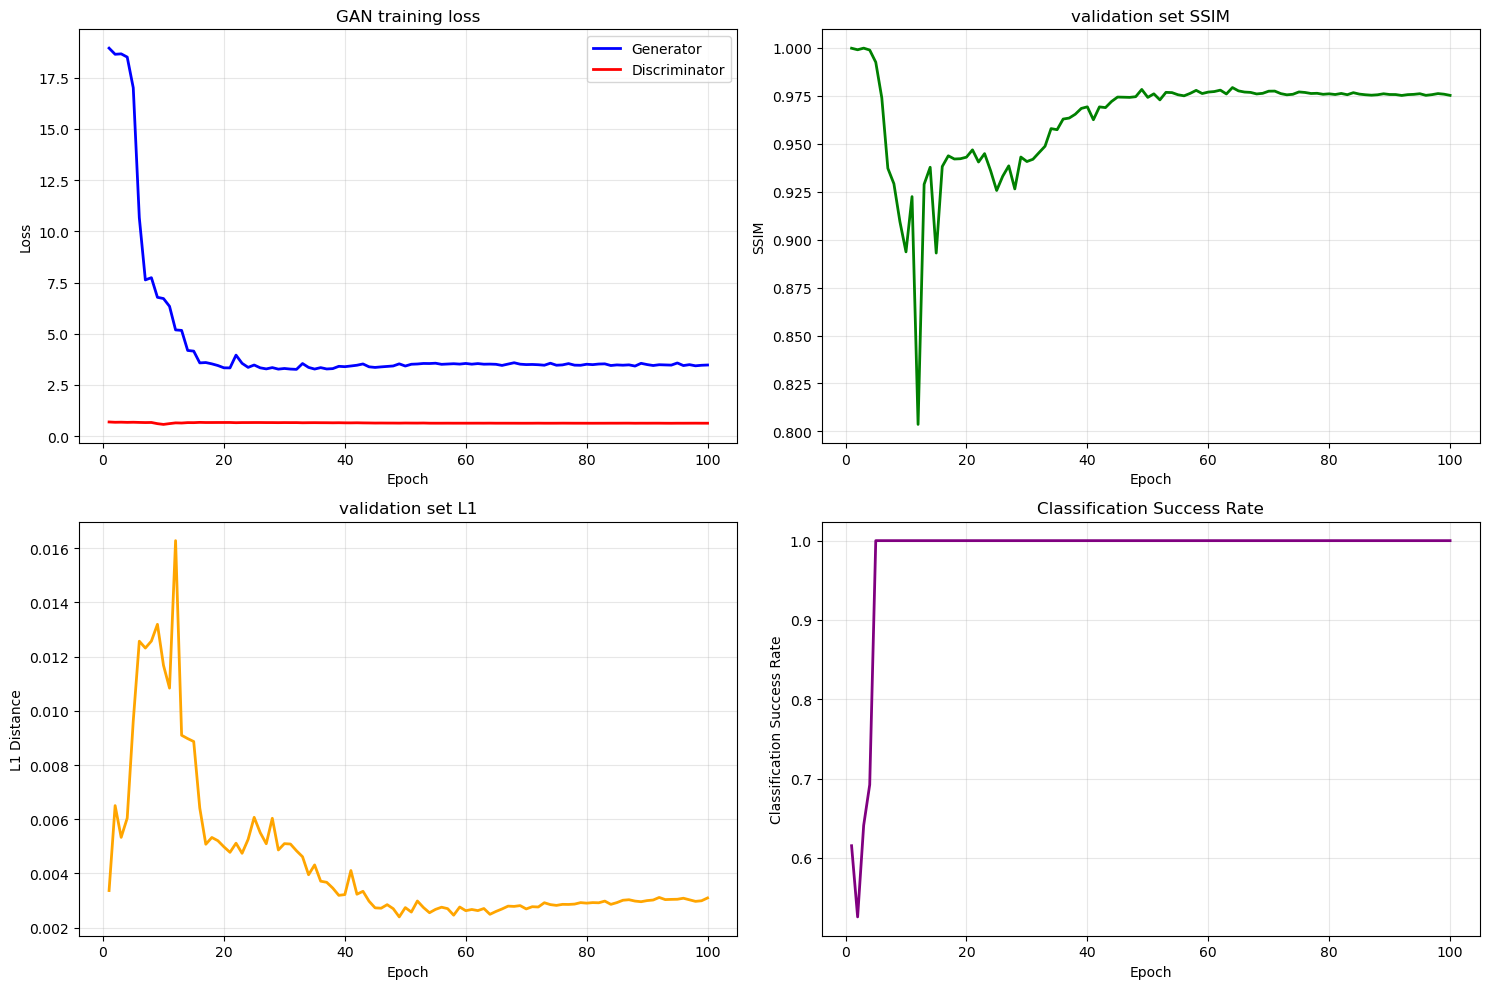

In [13]:
# %% [markdown]
# ## 9. 視覺化訓練過程

# %%
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs = range(1, len(history['g_loss']) + 1)

# GAN 損失
axes[0, 0].plot(epochs, history['g_loss'], 'b-', label='Generator', linewidth=2)
axes[0, 0].plot(epochs, history['d_loss'], 'r-', label='Discriminator', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('GAN training loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# SSIM
axes[0, 1].plot(epochs, history['val_ssim'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('SSIM')
axes[0, 1].set_title('validation set SSIM')
axes[0, 1].grid(True, alpha=0.3)

# L1 距離
axes[1, 0].plot(epochs, history['val_l1'], 'orange', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('L1 Distance')
axes[1, 0].set_title('validation set L1')
axes[1, 0].grid(True, alpha=0.3)

# 分類成功率
axes[1, 1].plot(epochs, history['val_cls_success'], 'purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Classification Success Rate')
axes[1, 1].set_title('Classification Success Rate')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "cgan_training.png", dpi=150, bbox_inches='tight')
plt.show()


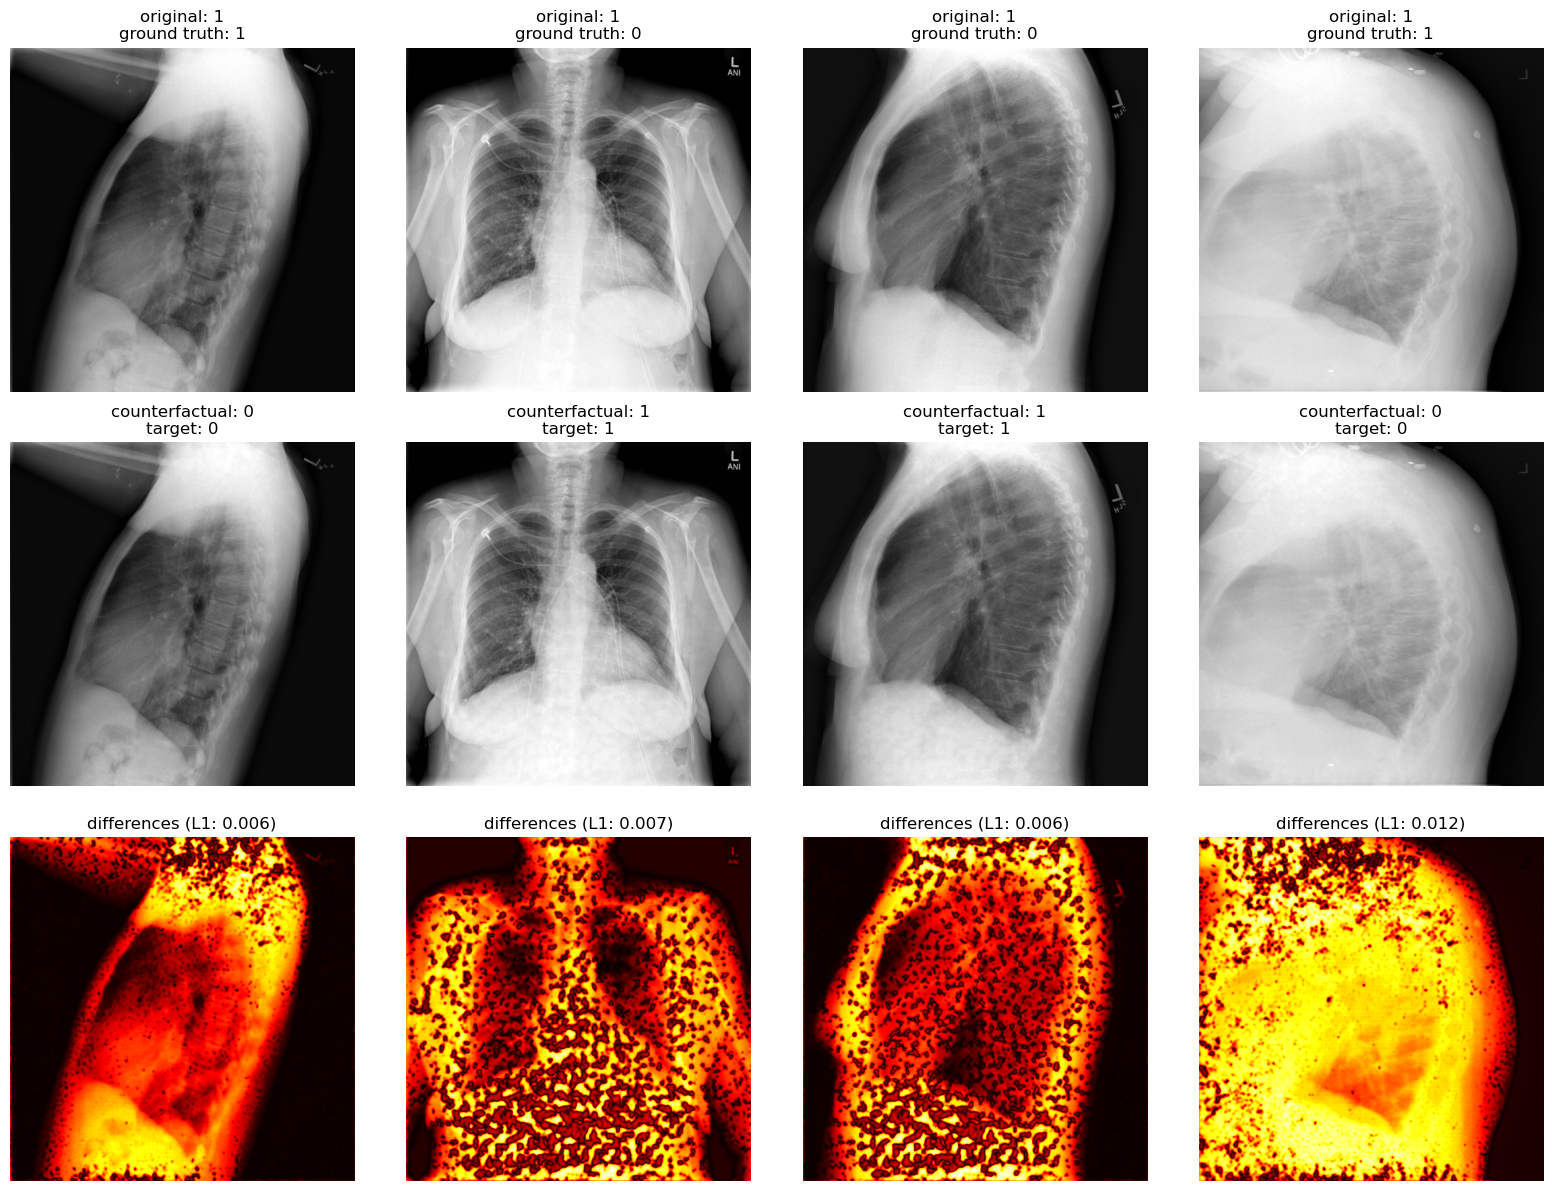


✅ cGAN 訓練完成！
最佳模型儲存於: d:\master\DGM\final_project\cxr-counterfactual-explanation\models\generator\best_cgan.pth
下一步：運行 05_counterfactual_analysis.ipynb 進行詳細分析


In [15]:
# %% [markdown]
# ## 10. 生成樣本測試

# %%
# 載入最佳模型
checkpoint = torch.load(MODELS_DIR / "best_cgan.pth")
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()

# 從驗證集取樣本
sample_images, sample_labels, sample_ids = next(iter(val_loader))
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

# 生成反事實
target_labels = 1 - sample_labels
target_labels_onehot = F.one_hot(target_labels, num_classes=2).float()

with torch.no_grad():
    cf_images = generator(sample_images, target_labels_onehot)
    
    # 檢查分類結果
    orig_logits = classifier(sample_images)
    cf_logits = classifier(cf_images)
    
    orig_preds = orig_logits.argmax(dim=1)
    cf_preds = cf_logits.argmax(dim=1)

# 視覺化
n_samples = min(4, sample_images.size(0))
fig, axes = plt.subplots(3, n_samples, figsize=(n_samples * 4, 12))

for i in range(n_samples):
    # 原始影像
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0)
    img = ((img + 1) / 2).clip(0, 1)
    if img.shape[2] == 3:
        img = img[:, :, 0]
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'original: {orig_preds[i].item()}\nground truth: {sample_labels[i].item()}')
    axes[0, i].axis('off')
    
    # 反事實影像
    cf_img = cf_images[i].cpu().numpy().transpose(1, 2, 0)
    cf_img = ((cf_img + 1) / 2).clip(0, 1)
    if cf_img.shape[2] == 3:
        cf_img = cf_img[:, :, 0]
    
    axes[1, i].imshow(cf_img, cmap='gray')
    axes[1, i].set_title(f'counterfactual: {cf_preds[i].item()}\ntarget: {target_labels[i].item()}')
    axes[1, i].axis('off')
    
    # 差異
    diff = np.abs(img - cf_img)
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].set_title(f'differences (L1: {diff.mean():.3f})')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "cgan_samples.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ cGAN 訓練完成！")
print(f"最佳模型儲存於: {MODELS_DIR / 'best_cgan.pth'}")
print(f"下一步：運行 05_counterfactual_analysis.ipynb 進行詳細分析")